In [3]:
import kagglehub
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
kagglehub.dataset_download("undefinenull/million-song-dataset-spotify-lastfm")

'C:\\Users\\saini\\.cache\\kagglehub\\datasets\\undefinenull\\million-song-dataset-spotify-lastfm\\versions\\1'

In [7]:
data_path = Path('C:\\Users\\saini\\.cache\\kagglehub\\datasets\\undefinenull\\million-song-dataset-spotify-lastfm\\versions\\1')

songs_data_path = data_path / 'Music Info.csv'
users_data_path = data_path / 'User Listening History.csv'

In [9]:
df_songs = pd.read_csv(songs_data_path)
df_songs.head()

,track_id,name,artist,spotify_preview_url,spotify_id,tags,genre,year,duration_ms,danceability,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,TRIOREW128F424EAF0,Mr. Brightside,The Killers,https://p.scdn.co/mp3-preview/4d26180e6961fd46...,09ZQ5TmUG8TSL56n0knqrj,"rock, alternative, indie, alternative_rock, in...",NaN,2004,222200,0.355,...,1,-4.360,1,0.0746,0.001190,0.000000,0.0971,0.240,148.114,4
1,TRRIVDJ128F429B0E8,Wonderwall,Oasis,https://p.scdn.co/mp3-preview/d012e536916c927b...,06UfBBDISthj1ZJAtX4xjj,"rock, alternative, indie, pop, alternative_roc...",NaN,2006,258613,0.409,...,2,-4.373,1,0.0336,0.000807,0.000000,0.2070,0.651,174.426,4
2,TROUVHL128F426C441,Come as You Are,Nirvana,https://p.scdn.co/mp3-preview/a1c11bb1cb231031...,0keNu0t0tqsWtExGM3nT1D,"rock, alternative, alternative_rock, 90s, grunge",RnB,1991,218920,0.508,...,4,-5.783,0,0.0400,0.000175,0.000459,0.0878,0.543,120.012,4
3,TRUEIND128F93038C4,Take Me Out,Franz Ferdinand,https://p.scdn.co/mp3-preview/399c401370438be4...,0ancVQ9wEcHVd0RrGICTE4,"rock, alternative, indie, alternative_rock, in...",NaN,2004,237026,0.279,...,9,-8.851,1,0.0371,0.000389,0.000655,0.1330,0.490,104.560,4
4,TRLNZBD128F935E4D8,Creep,Radiohead,https://p.scdn.co/mp3-preview/e7eb60e9466bc3a2...,01QoK9DA7VTeTSE3MNzp4I,"rock, alternative, indie, alternative_rock, in...",RnB,2008,238640,0.515,...,7,-9.935,1,0.0369,0.010200,0.000141,0.1290,0.104,91.841,4


Since we have already EDA and we know there are duplicates we will remove them

In [12]:
df_songs.shape

(50683, 21)

In [14]:
df_songs = df_songs.drop_duplicates(subset='spotify_id')

In [16]:
df_songs.reset_index(drop=True,inplace=True)

In [18]:
df_songs.shape

(50674, 21)

In [20]:
cols_to_remove = ["track_id","name","spotify_preview_url","spotify_id","genre"]

df_songs_filt = df_songs.drop(columns=cols_to_remove)

Since more than half of the genre column contains null values better we will remove well we have some similar kind of column known as tags we will use that and since we are deleting track_id too now but we need it later so we are storing useful data in new dataframe and we will use that

In [23]:
df_songs_filt.shape

(50674, 16)

In [25]:
df_songs_filt.head(1)

,artist,tags,year,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,The Killers,"rock, alternative, indie, alternative_rock, in...",2004,222200,0.355,0.918,1,-4.36,1,0.0746,0.00119,0.0,0.0971,0.24,148.114,4


Whatever columns that are present in df_songs_filt are useful to build our recommendation system

There will be some missing values from genre and tags column but since we have removed genre there will missing values from tags column

In [29]:
df_songs_filt.isna().sum()

artist                 0
tags                1126
year                   0
duration_ms            0
danceability           0
energy                 0
key                    0
loudness               0
mode                   0
speechiness            0
acousticness           0
instrumentalness       0
liveness               0
valence                0
tempo                  0
time_signature         0
dtype: int64

we will fill these missing values with no_tags

In [32]:
df_songs_filt.fillna({"tags" : "no_tags"} , inplace=True)

In [34]:
df_songs_filt.isna().sum()

artist              0
tags                0
year                0
duration_ms         0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
dtype: int64

We will make artist names in lower case

In [37]:
df_songs_filt["artist"] = df_songs_filt["artist"].str.lower()

In [39]:
df_songs_filt.head(1)

,artist,tags,year,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,the killers,"rock, alternative, indie, alternative_rock, in...",2004,222200,0.355,0.918,1,-4.36,1,0.0746,0.00119,0.0,0.0971,0.24,148.114,4


Now we will explore the this column slightly to see what trasformations we can apply to them

In [48]:
(
    df_songs
    .loc[:,'artist']
    .nunique()
)

8317

There are 8317 artists we can do two things. We can apply one hot encoding to this artists or we can combine both artists and tags column and we can tf-idf for combined. Well we filled null values as no_tags we will do first one if we have to apply second one we have to fill null values with empty string

We will apply count encoder to year column. Since there are 12 unique values in key column and 6 unique values in time_signature column we will apply one hot encoding to them. And as said before tf-idf technique is applied to tags column but we have to see how many max features we have include

In [52]:
(
    df_songs
    .loc[:,'tags']
    .str.lower()
    .str.split(',')
    .explode()
    .str.strip()
    .value_counts()
)

tags
rock            10681
indie            7284
electronic       6592
alternative      6271
pop              4650
                ...  
dark_ambient      602
japanese          489
polish            411
j_pop             213
russian           127
Name: count, Length: 100, dtype: int64

There are total 100 features in tags column but we will include only those whose value counts will be greater than equal to 1000

In [55]:
(
    df_songs
    .loc[:,'tags']
    .str.lower()
    .str.split(',')
    .explode()
    .str.strip()
    .value_counts()
    .loc[lambda ser: ser >= 1000]
)

tags
rock            10681
indie            7284
electronic       6592
alternative      6271
pop              4650
                ...  
ska              1088
gothic_metal     1072
grindcore        1040
french           1018
nu_metal         1006
Name: count, Length: 85, dtype: int64

So we will continue with max_features as 85

for continuous columns we have three columns(duration_ms , loudnes and temp) whose values are fixed in a range so we will normalize them using StandardScaler and there are columns whose values are from 0 to 1(danceability , energy , speechiness , acousticness , instrumentalness , liveness , valence) we will aply MinMaxScaler to them

In [59]:
#All tools for preprocessing
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OneHotEncoder
from category_encoders.count import CountEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer

In [60]:
frequency_encode_cols = ['year']
ohe_cols = ['artist',"time_signature","key"]
tfidf_col = 'tags'
standard_scale_cols = ["duration_ms","loudness","tempo"]
min_max_scale_cols = ["danceability","energy","speechiness","acousticness","instrumentalness","liveness","valence"]

We have seperated columns based on what pre-processing we do

In [64]:
transformer = ColumnTransformer(transformers=[
    ("frequency_encode", CountEncoder(normalize=True,return_df=True), frequency_encode_cols),
    ("ohe", OneHotEncoder(handle_unknown="ignore"), ohe_cols),
    ("tfidf", TfidfVectorizer(max_features=85), tfidf_col),
    ("standard_scale", StandardScaler(), standard_scale_cols),
    ("min_max_scale", MinMaxScaler(), min_max_scale_cols)
],remainder='passthrough',n_jobs=-1,force_int_remainder_cols=False)

In [66]:
transformer

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('frequency_encode', ...), ('ohe', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",-1
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and `

In [68]:
transformer.fit(df_songs_filt)

C:\Users\saini\anaconda3\Lib\site-packages\sklearn\compose\_column_transformer.py:978: FutureWarning: The parameter `force_int_remainder_cols` is deprecated and will be removed in 1.9. It has no effect. Leave it to its default value to avoid this warning.
  warnings.warn(


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('frequency_encode', ...), ('ohe', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",-1
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and `

In [70]:
transformed_df = transformer.transform(df_songs_filt)

In [72]:
transformed_df.shape

(50674, 8431)

Now let us analyze the shape of this tranformed_df We have one hot encoding to 3 columns that will be 8317 + 12 + 6, frequency encoding to one column that will be +1 , tf-idf with max_features=85 +85 and normalized 10 that will be +10 so in total it is 8431 and 50674 is number of rows in our dataframe

In [75]:
transformed_df

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 907911 stored elements and shape (50674, 8431)>

In [77]:
from sklearn.metrics.pairwise import cosine_similarity

We will use cosine-similarity to measure similarity between pair of vectors

Now first let us see how it works and then we will write a function to k similar songs

In [81]:
df_songs.loc[df_songs["artist"] == "Imagine Dragons"]

,track_id,name,artist,spotify_preview_url,spotify_id,tags,genre,year,duration_ms,danceability,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
87,TRXCSBC128E07943A1,Radioactive,Imagine Dragons,https://p.scdn.co/mp3-preview/da67866af09b9906...,07k45oBi6TbbwB2fxCcGl5,"rock, alternative, indie, alternative_rock, in...",NaN,2013,186653,0.471,...,9,-5.087,1,0.0616,0.133000,0.000002,0.7330,0.2320,136.351,4
252,TRAZEOK128F429E934,Demons,Imagine Dragons,https://p.scdn.co/mp3-preview/c710a1549dabd5e4...,0hGn9atxEyq7HRYTTk9r0R,"rock, alternative, indie, alternative_rock, in...",Rock,2014,175080,0.497,...,3,-5.038,1,0.0326,0.181000,0.000131,0.4320,0.3560,90.030,4
406,TRRHDAQ12903CAE809,It's Time,Imagine Dragons,https://p.scdn.co/mp3-preview/fab9f86f7f869304...,034tFGRsa8zNOV0Ph2WT9G,"rock, alternative, indie, pop, alternative_roc...",NaN,2012,238466,0.652,...,2,-4.665,1,0.0370,0.017600,0.000000,0.1020,0.8440,105.014,4
500,TRBNAIH12903CD9E41,On Top of the World,Imagine Dragons,https://p.scdn.co/mp3-preview/1913fbc88d454040...,00reVcwpg6Z9ERNHlaJ0XI,"rock, alternative, indie, pop, alternative_roc...",NaN,2013,190653,0.638,...,0,-6.247,1,0.1190,0.005600,0.000123,0.0880,0.8000,99.989,4
1773,TRUMEFQ128F92CA67B,Believer,Imagine Dragons,https://p.scdn.co/mp3-preview/a14b2a107bcd428e...,05KfyCEE6otdlT1pp2VIjP,"rock, alternative, indie, pop, alternative_roc...",NaN,2017,203782,0.772,...,10,-4.388,0,0.1120,0.041700,0.000000,0.2260,0.7480,124.978,4
1885,TRIUTMF128F934D532,Tiptoe,Imagine Dragons,https://p.scdn.co/mp3-preview/9da6444c7b160f20...,1ELZut15VsHXwocahE07oH,"rock, alternative, indie, alternative_rock, in...",NaN,2012,193000,0.527,...,1,-5.852,1,0.0318,0.001470,0.000026,0.0817,0.2400,120.047,4
1969,TRXGAXB128F4272C8F,Thunder,Imagine Dragons,https://p.scdn.co/mp3-preview/07e14c4e82117429...,0oP9pK1D1lNF3Lb7jkl6Xx,"rock, alternative, indie, pop, alternative_roc...",NaN,2017,187761,0.608,...,0,-3.798,1,0.0464,0.005930,0.057300,0.1210,0.2740,167.969,4
5330,TRIUXWM128F92E03B0,Hear Me,Imagine Dragons,https://p.scdn.co/mp3-preview/b44c4c06c61c5c23...,1c4wGo62FPdUMK6H0KtNLG,"rock, alternative, indie, alternative_rock, in...",Electronic,2012,232240,0.613,...,4,-4.694,1,0.0365,0.000328,0.000690,0.0765,0.5370,125.025,4
5677,TRBUOWV12903CA88E1,Warriors,Imagine Dragons,https://p.scdn.co/mp3-preview/73682a37925a46fe...,02SOn7MNKnGZYxm8Yx1ViX,"rock, indie, alternative_rock, indie_rock",Punk,2015,170080,0.355,...,4,-6.192,0,0.0720,0.068600,0.001840,0.2410,0.3410,78.017,4
5857,TRPFGGH128E078638E,Every Night,Imagine Dragons,https://p.scdn.co/mp3-preview/1c52857f65ee8087...,0CpQCN7nEz6tH6THwcJdzw,"rock, alternative, indie, alternative_rock, in...",NaN,2012,215533,0.478,...,0,-6.772,1,0.0280,0.053000,0.000041,0.1590,0.4240,139.808,4


Thses are all the songs by artist Imagine Dragons now let us take one of their song and predict top 10 songs which is similar to that song for now we are picking one of his famous songs named Demons

But we don't have song names in our new data frame thatt is why we kept our original dataframe safe and we will useful features from our new df

In [85]:
df_songs[df_songs["name"] == "Demons"]

,track_id,name,artist,spotify_preview_url,spotify_id,tags,genre,year,duration_ms,danceability,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
252,TRAZEOK128F429E934,Demons,Imagine Dragons,https://p.scdn.co/mp3-preview/c710a1549dabd5e4...,0hGn9atxEyq7HRYTTk9r0R,"rock, alternative, indie, alternative_rock, in...",Rock,2014,175080,0.497,...,3,-5.038,1,0.0326,0.181,0.000131,0.432,0.356,90.03,4


In [87]:
input_song = df_songs_filt[df_songs["name"] == "Demons"]

In [89]:
input_vector = transformer.transform(input_song)

input_vector

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 21 stored elements and shape (1, 8431)>

Which is the shape we needed since there is only one input song number of rows is one. Now we will calculate similarity scores with all the songs

In [92]:
similarity_scores = cosine_similarity(transformed_df,input_vector)

In [94]:
similarity_scores.shape

(50674, 1)

In [96]:
similarity_scores

array([[0.9999989 ],
       [0.99999824],
       [0.99999905],
       ...,
       [0.99999836],
       [0.99999899],
       [0.99999896]], shape=(50674, 1))

In [98]:
top_10_songs_indexes = np.argsort(similarity_scores.ravel())[-11:][::-1]

In [100]:
top_10_songs_indexes

array([  252,   500, 14163, 34710, 14178, 34442,  1885,   406,   886,
        5637,  5361])

In [102]:
top_10_songs_names = df_songs.iloc[top_10_songs_indexes]

In [104]:
top_10_songs_names

,track_id,name,artist,spotify_preview_url,spotify_id,tags,genre,year,duration_ms,danceability,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
252,TRAZEOK128F429E934,Demons,Imagine Dragons,https://p.scdn.co/mp3-preview/c710a1549dabd5e4...,0hGn9atxEyq7HRYTTk9r0R,"rock, alternative, indie, alternative_rock, in...",Rock,2014,175080,0.497,...,3,-5.038,1,0.0326,0.181000,0.000131,0.4320,0.356,90.030,4
500,TRBNAIH12903CD9E41,On Top of the World,Imagine Dragons,https://p.scdn.co/mp3-preview/1913fbc88d454040...,00reVcwpg6Z9ERNHlaJ0XI,"rock, alternative, indie, pop, alternative_roc...",NaN,2013,190653,0.638,...,0,-6.247,1,0.1190,0.005600,0.000123,0.0880,0.800,99.989,4
14163,TRCQPAL128F9314AE8,Natural,Imagine Dragons,https://p.scdn.co/mp3-preview/096c8cc00ba441a1...,2FY7b99s15jUprqC0M5NCT,"rock, alternative, indie, indie_rock, american...",NaN,2018,189466,0.704,...,2,-6.112,1,0.0409,0.217000,0.000000,0.0812,0.220,100.000,4
34710,TRUECGP128F4246502,Selene,Imagine Dragons,https://p.scdn.co/mp3-preview/2f8da30c1bc86c5a...,049BMnRoIIHH3V5E65N3Sh,"alternative, indie, alternative_rock, indie_ro...",Rock,2014,239813,0.566,...,0,-4.813,1,0.0254,0.000816,0.000005,0.1570,0.562,95.006,4
14178,TRDHEQV128F9342C94,My Fault,Imagine Dragons,https://p.scdn.co/mp3-preview/7da71aa3bc7af88d...,1BteyXYG96IcTLqRV0Zokq,"alternative, indie, indie_rock, american, male...",NaN,2012,175333,0.593,...,7,-6.179,1,0.0415,0.111000,0.017800,0.1120,0.497,108.486,4
34442,TRDDZKV12903CF2419,Starfall,Dragonland,https://p.scdn.co/mp3-preview/99bec014905b9196...,0ze5CtPn9K9J0by9L0aw3y,"power_metal, symphonic_metal",NaN,2004,199666,0.417,...,3,-3.277,1,0.0501,0.000129,0.001090,0.2770,0.439,98.424,4
1885,TRIUTMF128F934D532,Tiptoe,Imagine Dragons,https://p.scdn.co/mp3-preview/9da6444c7b160f20...,1ELZut15VsHXwocahE07oH,"rock, alternative, indie, alternative_rock, in...",NaN,2012,193000,0.527,...,1,-5.852,1,0.0318,0.001470,0.000026,0.0817,0.240,120.047,4
406,TRRHDAQ12903CAE809,It's Time,Imagine Dragons,https://p.scdn.co/mp3-preview/fab9f86f7f869304...,034tFGRsa8zNOV0Ph2WT9G,"rock, alternative, indie, pop, alternative_roc...",NaN,2012,238466,0.652,...,2,-4.665,1,0.0370,0.017600,0.000000,0.1020,0.844,105.014,4
886,TRZBMMA128F42872D2,Tongue Tied,Grouplove,https://p.scdn.co/mp3-preview/2147e7bd8762aa4f...,060CTIdsvB1FCDrYSougHk,"rock, electronic, alternative, indie, pop, ind...",NaN,2012,218013,0.560,...,3,-5.835,1,0.0439,0.008470,0.000000,0.1610,0.371,112.960,4
5637,TRYJMTE128F1486A8A,Why Do I Keep Counting?,The Killers,https://p.scdn.co/mp3-preview/cbf4256792f507d0...,1rwNgMn4DxpDAs0Dylj7JU,"rock, alternative, indie, alternative_rock, in...",Rock,2006,264453,0.566,...,3,-4.742,1,0.0404,0.016900,0.000018,0.0928,0.134,107.141,4


Well most of the songs our model predicting are from the same artists which is kinda good I mean the same artist prefers to make same kind of songs so they definitely they will be very similar Now let us do this for one more time. I will consider songs by Ellie Goulding

In [107]:
df_songs[df_songs["artist"] == "Ellie Goulding"]

,track_id,name,artist,spotify_preview_url,spotify_id,tags,genre,year,duration_ms,danceability,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
2176,TRDTDDW12903D08949,Starry Eyed,Ellie Goulding,https://p.scdn.co/mp3-preview/637a4b4e0ac31e54...,04XVVnYIZAQM7SeVeOx2hO,"electronic, indie, pop, female_vocalists, danc...",Pop,2010,178053,0.504,...,5,-7.061,0,0.0348,0.3560,0.000026,0.0965,0.6280,149.817,4
2178,TRACDNH128F931797F,Burn,Ellie Goulding,https://p.scdn.co/mp3-preview/e4e69842123c1e10...,0541Jjb5DigArUhmo2kvBP,"electronic, indie, pop, female_vocalists, danc...",NaN,2014,230040,0.387,...,10,-8.765,0,0.0517,0.4020,0.000000,0.1030,0.3280,116.045,5
2337,TRAZLUU128F426B6B2,Anything Could Happen,Ellie Goulding,https://p.scdn.co/mp3-preview/ee7fa20152ca009b...,09scPeVcx4VrRctxrcBw7k,"electronic, indie, pop, female_vocalists, brit...",NaN,2014,230600,0.526,...,0,-5.010,1,0.0393,0.1010,0.000002,0.1860,0.1980,205.913,4
2594,TRPGOJC12903CD710C,The Writer,Ellie Goulding,https://p.scdn.co/mp3-preview/f492cac62e6a82c5...,0uBWMWm5P6tuCiavbjPWS0,"electronic, indie, pop, female_vocalists, brit...",NaN,2010,251040,0.500,...,9,-5.354,1,0.0307,0.1670,0.000000,0.1160,0.2540,104.924,3
2678,TRFQGMU12903D0F9BA,This Love (Will Be Your Downfall),Ellie Goulding,https://p.scdn.co/mp3-preview/32da5ac70a9c2931...,0j5sEwTkXDBQOeS5aKsX85,"electronic, indie, pop, female_vocalists, danc...",Pop,2010,233573,0.582,...,3,-6.655,0,0.0297,0.1300,0.012400,0.1130,0.4330,109.468,4
2781,TRIMYQA128F429C948,On My Mind,Ellie Goulding,https://p.scdn.co/mp3-preview/002754bcc8856f6f...,1BVB23zGFAofViuK0jQlqL,"electronic, pop, dance, british, indie_pop, gu...",NaN,2016,211253,0.691,...,2,-6.799,0,0.0546,0.2540,0.000002,0.1520,0.7200,154.963,4
2783,TRTHNND12903D0F9E0,Every Time You Go,Ellie Goulding,https://p.scdn.co/mp3-preview/a681f1fee7829af1...,0c3N3991ucDuH9kOEzCBUd,"electronic, indie, pop, female_vocalists, brit...",Pop,2011,205093,0.623,...,5,-5.364,0,0.0304,0.0297,0.000000,0.1320,0.4650,108.982,4
2883,TRMNEAZ128F42A6C97,Your Biggest Mistake,Ellie Goulding,https://p.scdn.co/mp3-preview/693a53ccdd1778fb...,0Di9bVr9kej3oMs1K08k3J,"electronic, indie, pop, female_vocalists, danc...",NaN,2010,206186,0.571,...,5,-5.781,1,0.0279,0.0921,0.000000,0.0945,0.5810,122.992,4
2963,TROEZYL128E0792844,Figure 8,Ellie Goulding,https://p.scdn.co/mp3-preview/e6ae9a188b7cad5c...,0pUPzrMyxrN9eqDBWmCQYh,"electronic, pop, female_vocalists, british, ch...",NaN,2012,247439,0.378,...,7,-4.428,0,0.0556,0.0273,0.000000,0.1030,0.2450,147.907,4
3029,TRUPYUP12903D0FA06,Salt Skin,Ellie Goulding,https://p.scdn.co/mp3-preview/346ab226a74749d2...,0JfDRRBz2iFunxuIXJwqsJ,"electronic, pop, female_vocalists, british, sy...",Pop,2010,255813,0.498,...,0,-5.323,0,0.0488,0.1150,0.003420,0.1040,0.7740,172.065,4


We will consider song Love Me Like You Do

In [110]:
df_songs[df_songs["name"] == "Love Me Like You Do"]

,track_id,name,artist,spotify_preview_url,spotify_id,tags,genre,year,duration_ms,danceability,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
21302,TRLWHJN128F428ECBD,Love Me Like You Do,Ellie Goulding,https://p.scdn.co/mp3-preview/61dae7a818e6ea33...,0Cy7wt6IlRfBPHXXjmZbcP,"pop, chillout, soundtrack, love, beautiful, sy...",NaN,2018,253520,0.489,...,5,-6.633,0,0.0292,0.27,0.0,0.105,0.324,95.012,4


In [112]:
input_song = df_songs_filt[df_songs["name"] == "Love Me Like You Do"]

In [114]:
input_vector = transformer.transform(input_song)

In [116]:
input_vector

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 20 stored elements and shape (1, 8431)>

In [118]:
similarity_scores = cosine_similarity(transformed_df,input_vector)

In [120]:
print(similarity_scores.shape)
print(similarity_scores)

(50674, 1)
[[0.99999867]
 [0.99999824]
 [0.99999913]
 ...
 [0.99999859]
 [0.99999915]
 [0.99999866]]


In [122]:
top_10_songs_indexes = np.argsort(similarity_scores.ravel())[-11:][::-1]

In [124]:
top_10_songs_indexes

array([21302,  2783,  3348, 37159, 44066, 34535,  2678, 45017, 34578,
       20621, 29620])

In [126]:
df_songs.iloc[top_10_songs_indexes]

,track_id,name,artist,spotify_preview_url,spotify_id,tags,genre,year,duration_ms,danceability,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
21302,TRLWHJN128F428ECBD,Love Me Like You Do,Ellie Goulding,https://p.scdn.co/mp3-preview/61dae7a818e6ea33...,0Cy7wt6IlRfBPHXXjmZbcP,"pop, chillout, soundtrack, love, beautiful, sy...",NaN,2018,253520,0.489,...,5,-6.633,0,0.0292,0.270000,0.000000,0.105,0.3240,95.012,4
2783,TRTHNND12903D0F9E0,Every Time You Go,Ellie Goulding,https://p.scdn.co/mp3-preview/a681f1fee7829af1...,0c3N3991ucDuH9kOEzCBUd,"electronic, indie, pop, female_vocalists, brit...",Pop,2011,205093,0.623,...,5,-5.364,0,0.0304,0.029700,0.000000,0.132,0.4650,108.982,4
3348,TRUMQID128F1467D6A,Explosions,Ellie Goulding,https://p.scdn.co/mp3-preview/581f74c275da9753...,03jaL9epJaHFFnoRA9RmWK,"electronic, pop, female_vocalists, british, ch...",Rock,2013,245320,0.427,...,5,-8.170,1,0.0308,0.702000,0.000000,0.290,0.1420,95.770,4
37159,TRPBVBZ128F4289141,Good Together,Honne,https://p.scdn.co/mp3-preview/2c14d1a20627df9e...,1CGFRLU9HCOnvrmB2H6sNo,"pop, love, synthpop",NaN,2016,228521,0.683,...,5,-5.460,0,0.0293,0.087400,0.000487,0.133,0.5070,96.990,4
44066,TRMNXWZ128F930B396,Fiji,Taco Hemingway,https://p.scdn.co/mp3-preview/69be30d86f38f49c...,2CdCs9y04oDuYCF4ewNzI7,polish,NaN,2018,242560,0.774,...,5,-5.569,0,0.1220,0.197000,0.002330,0.122,0.3510,104.996,4
34535,TRUHHBX128F425F0D2,Innocent World,Freedom Call,https://p.scdn.co/mp3-preview/c34044286672a024...,2LlOIg3RFaDyCQcbW50NkX,power_metal,NaN,2007,266666,0.488,...,5,-4.689,0,0.0616,0.001490,0.000022,0.257,0.2510,90.068,4
2678,TRFQGMU12903D0F9BA,This Love (Will Be Your Downfall),Ellie Goulding,https://p.scdn.co/mp3-preview/32da5ac70a9c2931...,0j5sEwTkXDBQOeS5aKsX85,"electronic, indie, pop, female_vocalists, danc...",Pop,2010,233573,0.582,...,3,-6.655,0,0.0297,0.130000,0.012400,0.113,0.4330,109.468,4
45017,TRMKZYN128F42575D0,Visionary,Rameses B,https://p.scdn.co/mp3-preview/0d3ce5dd75babe9d...,02er92Dig6SfHgk6etFjRK,drum_and_bass,NaN,2015,297500,0.536,...,5,-5.743,0,0.0545,0.000642,0.134000,0.414,0.1360,87.503,4
34578,TRMCEVH128F92FB497,Rise Again,Kamelot,https://p.scdn.co/mp3-preview/f16992b245f8d74c...,1lfvXd7SfspT2jg5Zo5JxX,power_metal,NaN,1996,246906,0.577,...,5,-8.554,0,0.0474,0.000042,0.020600,0.160,0.0392,106.285,4
20621,TRDQEEH128E07844F2,Water Under The Bridge,Adele,https://p.scdn.co/mp3-preview/a56f58462f4b6976...,6VZdDF6AgZHWiJfgs3T86v,"pop, british, soul, electro, synthpop, pop_rock",Rock,2016,240426,0.596,...,5,-6.520,0,0.0704,0.018900,0.000015,0.108,0.4720,94.982,4


Now we will write the function(recommend) which recommends top k songs similar to the given song  
  
Input:  
son_name(str) , songs_data(DataFrame) , k(default value will be 7)  
  
Output:  
DataFrame(Consisting of top k songs)

In [155]:
def recommend(song_name, songs_data, transformed_data, k=7):
    # filter out the song from data
    song_row = songs_data.loc[songs_data["name"] == song_name,:]
    if song_row.empty:
        print("Song not found in the dataset.")
    else:
        # get the index of song
        song_index = song_row.index[0]
        # generate the input vector
        input_vector = transformed_data[song_index].reshape(1 , -1)
        # calculate similarity scores
        similarity_scores = cosine_similarity(input_vector, transformed_data)
        # get the top k songs
        similarity_scores = similarity_scores.ravel()

        top_k_songs_indexes = (
            np.argsort(similarity_scores)[::-1]
        )

        top_k_songs_indexes = top_k_songs_indexes[
            top_k_songs_indexes != song_index
        ][:k]
        # get the top k songs names
        top_k_songs_names = songs_data.iloc[top_k_songs_indexes]
        # print the top k songs
        top_k_list = top_k_songs_names.reset_index(drop=True)
        return top_k_list

Now let us test for Demons song what our function returns

In [162]:
pred1 = recommend("Demons" , df_songs , transformed_df , k=7)

In [164]:
pred2 = recommend("Love Me Like You Do" , df_songs , transformed_df , 10)

Now we have to do some evaluation like how good our model is performing

In [167]:
pred1[["name" , "artist" , "tags"]]

,name,artist,tags
0,On Top of the World,Imagine Dragons,"rock, alternative, indie, pop, alternative_roc..."
1,Natural,Imagine Dragons,"rock, alternative, indie, indie_rock, american..."
2,Selene,Imagine Dragons,"alternative, indie, alternative_rock, indie_ro..."
3,My Fault,Imagine Dragons,"alternative, indie, indie_rock, american, male..."
4,Starfall,Dragonland,"power_metal, symphonic_metal"
5,Tiptoe,Imagine Dragons,"rock, alternative, indie, alternative_rock, in..."
6,It's Time,Imagine Dragons,"rock, alternative, indie, pop, alternative_roc..."


let us analyze this

In [170]:
pred1["artist"].value_counts()

artist
Imagine Dragons    6
Dragonland         1
Name: count, dtype: int64

Well lot of predictions are from same artists because we have used almost 8000 features for artist it is also good like many people prefer listening to similar artist

In [174]:
pred2["artist"].value_counts()

artist
Ellie Goulding    3
Honne             1
Taco Hemingway    1
Freedom Call      1
Rameses B         1
Kamelot           1
Adele             1
Disclosure        1
Name: count, dtype: int64

Almost similar for second one too but here artist is more diverse

So we can say our model depends on artist but not giving same artist songs

Now we will analyze tags column

In [179]:
pred1["tags"]

0    rock, alternative, indie, pop, alternative_roc...
1    rock, alternative, indie, indie_rock, american...
2    alternative, indie, alternative_rock, indie_ro...
3    alternative, indie, indie_rock, american, male...
4                         power_metal, symphonic_metal
5    rock, alternative, indie, alternative_rock, in...
6    rock, alternative, indie, pop, alternative_roc...
Name: tags, dtype: object

In [185]:
pred1_tags = (
    pred1["tags"]
    .str.split(",")
    .explode()
    .value_counts()
)

In [187]:
original1_tags = (
    df_songs[df_songs["name"] == "Demons"]["tags"]
    .str.split(",")
    .explode()
    .value_counts()
)

In [203]:
comparison1 = pd.concat(
    [original1_tags, pred1_tags],
    axis=1
).fillna(0)

comparison1.columns = [
    "Demons",
    "Recommendations"
]

comparison1.sort_values(
    by="Recommendations",
    ascending=False,
    inplace=True
)

In [205]:
comparison1.head(7)

,Demons,Recommendations
tags,,
indie,1.0,6
indie_rock,1.0,6
rock,1.0,4
alternative,1.0,4
alternative_rock,1.0,4
american,1.0,4
male_vocalists,0.0,3


well we can see prediction tags are almost similar to original song's tags

Now let us do same thing for our next song too

In [213]:
pred2_tags = (
    pred2["tags"]
    .str.split(",")
    .explode()
    .value_counts()
)

original2_tags = (
    df_songs[df_songs["name"] == "Love Me Like You Do"]["tags"]
    .str.split(",")
    .explode()
    .value_counts()
)

comparison2 = pd.concat(
    [original2_tags, pred2_tags],
    axis=1
).fillna(0)

comparison2.columns = [
    "Love Me Like You Do",
    "Recommendations"
]

comparison2.sort_values(
    by="Recommendations",
    ascending=False,
    inplace=True
)

In [215]:
comparison2

,Love Me Like You Do,Recommendations
tags,,
british,0.0,4.0
synthpop,1.0,3.0
pop,0.0,3.0
female_vocalists,0.0,3.0
electronic,0.0,3.0
pop,1.0,2.0
indie_pop,0.0,2.0
indie,0.0,2.0
power_metal,0.0,2.0


Which is good but not as good as the before song

Now let us compare based on audio_cols

In [222]:
audio_cols = [
    "danceability",
    "energy",
    "valence",
    "tempo"
]

original2 = (
    df_songs
    .loc[df_songs["name"]=="Love Me Like You Do", audio_cols]
)

comparison2 = pd.DataFrame({
    "Original": original2.iloc[0],
    "Recommended Mean": pred1[audio_cols].mean()
})

comparison2

,Original,Recommended Mean
danceability,0.489,0.585286
energy,0.597,0.800857
valence,0.324,0.514571
tempo,95.012,103.852286


Results are good but not quite amazing there are more shifts in energy and valence which tells model is predicting more happy and energitic songs than this

In [227]:
original1 = (
    df_songs
    .loc[df_songs["name"]=="Demons", audio_cols]
)

comparison1 = pd.DataFrame({
    "Original": original1.iloc[0],
    "Recommended Mean": pred2[audio_cols].mean()
})

comparison1

,Original,Recommended Mean
danceability,0.497,0.61340
energy,0.666,0.76450
valence,0.356,0.35542
tempo,90.030,100.30640


It is quite good that valence is almost identical and there are little changes in danceability, energy but tempo differs

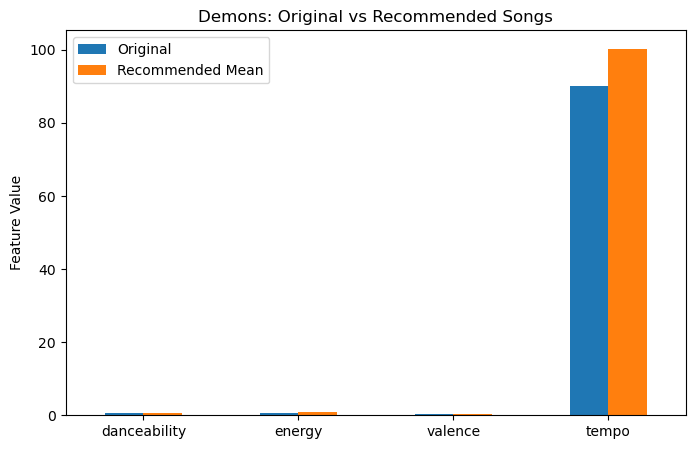

In [230]:
comparison1.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Demons: Original vs Recommended Songs")
plt.ylabel("Feature Value")
plt.xticks(rotation=0)
plt.show()

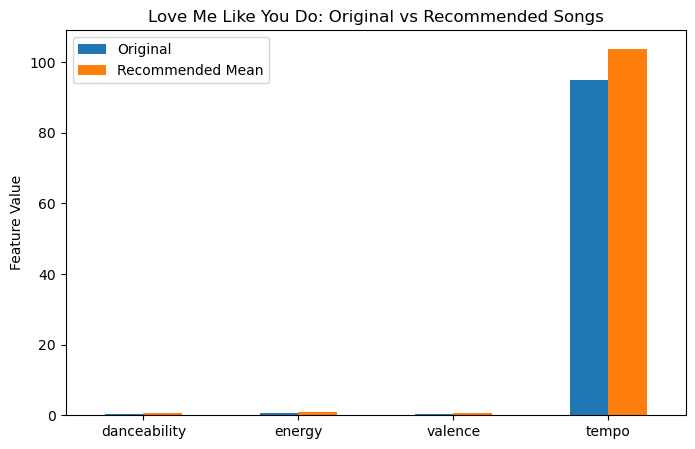

In [232]:
comparison2.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Love Me Like You Do: Original vs Recommended Songs")
plt.ylabel("Feature Value")
plt.xticks(rotation=0)
plt.show()